# Predictive Maintenance — Failure Risk Score (Logistic Regression)
**Skripsi: Predictive Maintenance pada Industri Pertambangan (PT X)** | Periode Januari–Agustus 2025

---

Notebook ini mengikuti **metodologi BAB 3**: analisis kuantitatif non-eksperimental atas data operasional sekunder untuk menghasilkan **Failure Risk Score (FRS)** melalui **Logistic Regression**, kemudian menguji **Proposisi Analitis 2** — hubungan antara **indikator Maintenance KPI** dan **indikator nilai operasional**.

> **Unit analisis (BAB 3):** *equipment-level monthly performance data*. Karena dataset mentah berupa *log downtime* tanpa kolom ID unit, **kategori komponen** dipakai sebagai **proxy unit peralatan** (lihat Keterbatasan). Setiap observasi panel = satu (komponen × bulan).

## Alur sesuai BAB 3

| Tahap BAB 3 | Implementasi |
|---|---|
| 3.6.1 Validitas Data (cleaning) | Phase 1–2: pembersihan, *forward-fill* merged cells, kategorisasi komponen |
| **3.3.3 Perhitungan Maintenance KPI** | Phase 3: agregasi panel → **MTBF, Availability, Downtime Rate** |
| **3.3.4 Pemodelan Predictive Maintenance** | Phase 5–6: Logistic Regression klasifikasi failure/non-failure |
| **Analisis Failure Risk Score** | Phase 7: FRS = P(Y=1) per (komponen × bulan) |
| **3.6.4 Validitas Model** | Train-test split + Accuracy, Precision, Recall, AUC-ROC, Confusion Matrix |
| **Pengujian Proposisi Analitis 2** | Phase 9: korelasi Pearson **KPI ↔ Downtime Cost / Production Loss / Budget Variance** |

## Rumus (BAB 3, Tabel 3.2 & 3.7)

| Indikator | Rumus | Skala |
|---|---|---|
| **MTBF** | Total Operating Time / Number of Failures | Jam |
| **Availability** | Operating Time / (Operating Time + Total Downtime) | Rasio |
| **Downtime Rate** | Total Downtime / Total Scheduled Time | Rasio |
| **Failure Risk Score** | P(Y=1) dari Logistic Regression | 0–1 |
| **Downtime Cost** | Downtime Hours × Cost per Hour → kolom `DT Cost` | Currency |
| **Production Loss** | Downtime Hours × Output Rate → kolom `Production Loss (Tons)` | Tons |
| **Budget Variance** | Actual Maintenance Cost − Planned Mtc. Cost | Currency |

**Catatan metodologi:** Logistic Regression adalah **model utama**. Random Forest hanya **satu pembanding**. (**Proposisi 1 di-skip** sesuai arahan; fokus pada **Proposisi 2**.)

---
## Phase 0 — Setup & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, shutil, tempfile, warnings, joblib
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=='notebook' else os.getcwd()
DIR_MODELS, DIR_OUTPUTS, DIR_REPORT = (os.path.join(BASE,x) for x in ('models','outputs','report'))
for d in (DIR_MODELS, DIR_OUTPUTS, DIR_REPORT): os.makedirs(d, exist_ok=True)
XLSX = os.path.join(os.path.dirname(BASE), 'raw data – skripsi (ANASTASYA NAJENDRA).xlsx')
print('Dataset :', os.path.basename(XLSX))
print('Output  :', BASE)

Dataset : raw data – skripsi (ANASTASYA NAJENDRA).xlsx
Output  : C:\Users\LEGION\OneDrive - Telkom University\KULIAH\JOKI\pred_maintenance


---
## Phase 1 — Dataset Understanding

Mengidentifikasi struktur data, missing value, duplikat, dan kesiapan membentuk panel equipment-bulanan serta indikator nilai operasional.

In [2]:
def load_raw(path):
    # Baca Excel; jika file sedang dibuka di Excel (terkunci), pakai/buat salinan sementara
    tmp = os.path.join(tempfile.gettempdir(), 'pm_raw.xlsx')
    try:
        return pd.read_excel(path, sheet_name='jan', header=2)
    except PermissionError:
        if not os.path.exists(tmp):
            shutil.copy(path, tmp)   # kalau gagal: tutup file Excel-nya lalu jalankan ulang
        return pd.read_excel(tmp, sheet_name='jan', header=2)

raw = load_raw(XLSX)
print('Shape mentah:', raw.shape)
info = pd.DataFrame({'dtype':raw.dtypes.astype(str), 'non_null':raw.notna().sum(),
                     'missing':raw.isna().sum(), 'n_unique':raw.nunique()})
print('Duplikat baris:', raw.duplicated().sum())
info

Shape mentah: (1718, 12)
Duplikat baris: 93


,dtype,non_null,missing,n_unique
Unnamed: 0,float64,0,1718,0
Months,object,8,1710,8
Date (mm/dd/yy),object,241,1477,241
Status,object,1718,0,2
Description,object,1718,0,1238
Total DT Hours,object,1718,0,484
Planned Operating Time,int64,1718,0,1
Unnamed: 7,float64,0,1718,0
DT Cost (avg/day),float64,241,1477,237
Production Loss Est. (Raw Ore in Tons),float64,241,1477,113


### Temuan Phase 1
- Kolom **`Status` konstan** `"Unplanned Down"` → tiap baris adalah event downtime; **tidak ada label kegagalan eksplisit** (lihat Phase 5).
- Kolom **merged cells** (nilai hanya di awal blok): `Months`, `Date`, **`DT Cost`**, **`Production Loss`**, **`Maintenace Cost (after DT)`**, **`Planned Mtc. Cost`** → diisi *forward-fill*.
- **Dataset versi lengkap**: indikator nilai operasional (`Production Loss`, `Maintenance Cost` aktual, `Planned Mtc. Cost`) **kini tersedia** → memungkinkan **Proposisi 2**.
- **Tidak ada ID unit peralatan** → kategori komponen dipakai sebagai proxy unit.

---
## Phase 2 — Data Preprocessing (Validitas Data, BAB 3.6.1)

Prosedur: cleaning baris rusak, *forward-fill* merged cells (termasuk indikator nilai), penandaan **blok harian**, konversi numerik, dan kategorisasi komponen.

In [3]:
df = raw.copy()
# 1) Buang baris rusak
bad = ~df['Status'].astype(str).str.contains('Down', na=False)
print('Baris rusak dibuang :', int(bad.sum()))
df = df[~bad].copy()

# 2) Penanda BLOK harian dari sel ter-merge (tiap nilai DT Cost baru = blok baru) -- sebelum ffill
DTC='DT Cost (avg/day)'; PL='Production Loss Est. (Raw Ore in Tons)'
ACT='Maintenace Cost (after DT)'; PLN='Planned Mtc. Cost'
df['block'] = pd.to_numeric(df[DTC], errors='coerce').notna().cumsum()

# 3) Forward-fill merged cells
df['Months'] = df['Months'].ffill()
df['Date (mm/dd/yy)'] = df['Date (mm/dd/yy)'].ffill()
df['DT_Cost']    = pd.to_numeric(df[DTC], errors='coerce').ffill()
df['ProdLoss']   = pd.to_numeric(df[PL],  errors='coerce').ffill()
df['MtcActual']  = pd.to_numeric(df[ACT], errors='coerce').ffill()
df['PlannedMtc'] = pd.to_numeric(df[PLN], errors='coerce').ffill()
for c in ['DT_Cost','ProdLoss','MtcActual','PlannedMtc']:
    df[c] = df[c].fillna(df[c].median())
df['BudgetVar'] = df['MtcActual'] - df['PlannedMtc']   # Maintenance Budget Variance

# 4) Numerik downtime & planned
df['DT_Hours'] = pd.to_numeric(df['Total DT Hours'], errors='coerce')
df = df.dropna(subset=['DT_Hours']).copy()
df['Planned'] = pd.to_numeric(df['Planned Operating Time'], errors='coerce').fillna(24.0)

# 5) Bulan -> indeks 1..8
order = ['January','February','March','April','May','June','July','August']
df['mname'] = df['Months'].astype(str).str.extract(r'^(\w+)')[0]
df['midx'] = df['mname'].map({m:i+1 for i,m in enumerate(order)})
print('Jumlah event final :', len(df), '| jumlah blok harian:', df['block'].nunique())

Baris rusak dibuang : 1
Jumlah event final : 1716 | jumlah blok harian: 241


In [4]:
# 6) Kategorisasi komponen (proxy unit peralatan)
def categorize(desc):
    d = str(desc).upper()
    rules = [
        ('Tire/Wheel',      ['TIRE','TYRE','WHEEL','RIM','BAN']),
        ('Brake',           ['BRAKE','PARKING']),
        ('Engine/Fuel',     ['ENGINE','START','INJECTOR','TURBO','FUEL','RADIATOR','OVERHEAT','OIL']),
        ('Electrical/Lamp', ['LAMP','LIGHT','SIGNAL','INDICATOR','DASH','SPEEDO','ODO','BATTERY','HORN','WIPER','PANEL']),
        ('Steering',        ['STEERING','KNUCKLE']),
        ('Driveline/Trans', ['DRIVELINE','DRIVE LINE','TRANSMISSION','CLUTCH','GEAR','AXLE','DIFF','PROPELLER']),
        ('Body/Cabin',      ['DOOR','SEAT','CABIN','GLASS','MIRROR','WINDOW','HINGE','BODY']),
        ('Suspension',      ['SUSPENSION','SHOCK','SPRING','BUSHING']),
        ('Hydraulic',       ['HYDRAULIC','CYLINDER','PUMP','HOSE','LEAK']),
    ]
    for name, kws in rules:
        if any(k in d for k in kws): return name
    return 'Other'
df['component'] = df['Description'].apply(categorize)
print('Distribusi event per kategori komponen:')
print(df['component'].value_counts())

Distribusi event per kategori komponen:
component
Other              396
Engine/Fuel        393
Brake              192
Electrical/Lamp    166
Driveline/Trans    117
Hydraulic          107
Tire/Wheel          96
Body/Cabin          89
Steering            82
Suspension          78
Name: count, dtype: int64


---
## Phase 3 — Perhitungan Maintenance KPI (BAB 3.3.3)

Panel **(komponen × bulan)**. Untuk tiap sel dihitung **MTBF, Availability, Downtime Rate**.
- *Total Scheduled Time* = hari/bulan × 24 jam; *Number of Failures* = jumlah event; *Operating* = Scheduled − Downtime.

In [5]:
DAYS = {1:31,2:28,3:31,4:30,5:31,6:30,7:31,8:31}
panel = (df.groupby(['component','midx'])
           .agg(N_fail=('DT_Hours','size'), DT_total=('DT_Hours','sum'),
                DT_Cost_total=('DT_Cost','sum'))
           .reset_index())
panel['Scheduled']     = panel['midx'].map(DAYS) * 24.0
panel['Operating']     = (panel['Scheduled'] - panel['DT_total']).clip(lower=1.0)
panel['MTBF']          = panel['Operating'] / panel['N_fail']
panel['Availability']  = panel['Operating'] / panel['Scheduled']
panel['Downtime_Rate'] = panel['DT_total'] / panel['Scheduled']
panel['dt_cost_log']   = np.log1p(panel['DT_Cost_total'])
panel.to_csv(os.path.join(DIR_OUTPUTS,'kpi_panel.csv'), index=False)
print(f'Panel: {panel.shape[0]} baris ({panel.component.nunique()} komponen x {panel.midx.nunique()} bulan)')
panel[['MTBF','Availability','Downtime_Rate','N_fail']].describe().round(3)

Panel: 78 baris (10 komponen x 8 bulan)


,MTBF,Availability,Downtime_Rate,N_fail
count,78.000,78.000,78.000,78.000
mean,51.342,0.570,0.468,22.000
std,63.788,0.302,0.401,17.551
min,0.013,0.001,0.040,2.000
25%,9.101,0.409,0.181,8.000
50%,27.972,0.638,0.362,16.000
75%,72.409,0.819,0.591,29.500
max,355.960,0.960,2.154,76.000


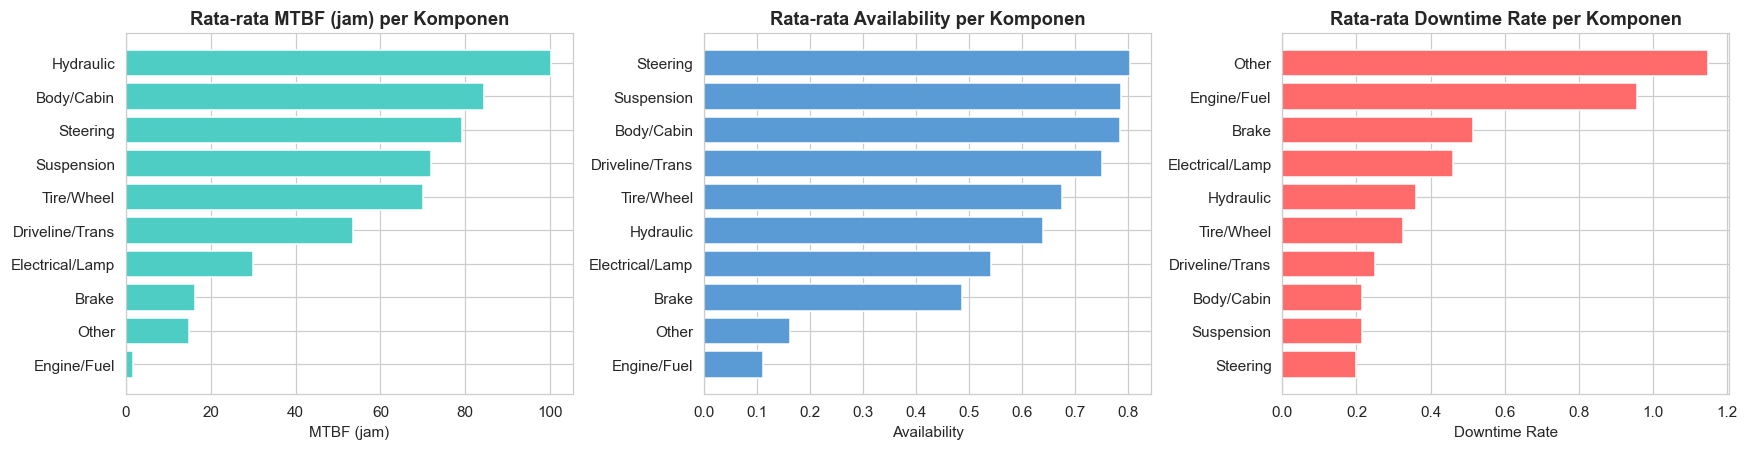

Insight: komponen dgn MTBF rendah & Downtime Rate tinggi = keandalan rendah (prioritas maintenance).


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a,(col,ttl,c) in zip(ax, [('MTBF','MTBF (jam)','#4ECDC4'),('Availability','Availability','#5B9BD5'),
                               ('Downtime_Rate','Downtime Rate','#FF6B6B')]):
    m = panel.groupby('component')[col].mean().sort_values()
    a.barh(m.index, m.values, color=c, edgecolor='white'); a.set_title(f'Rata-rata {ttl} per Komponen', fontweight='bold'); a.set_xlabel(ttl)
plt.tight_layout(); plt.savefig(os.path.join(DIR_OUTPUTS,'kpi_distribution.png'), dpi=130, bbox_inches='tight'); plt.show()
print('Insight: komponen dgn MTBF rendah & Downtime Rate tinggi = keandalan rendah (prioritas maintenance).')

---
## Phase 4 — Exploratory Data Analysis

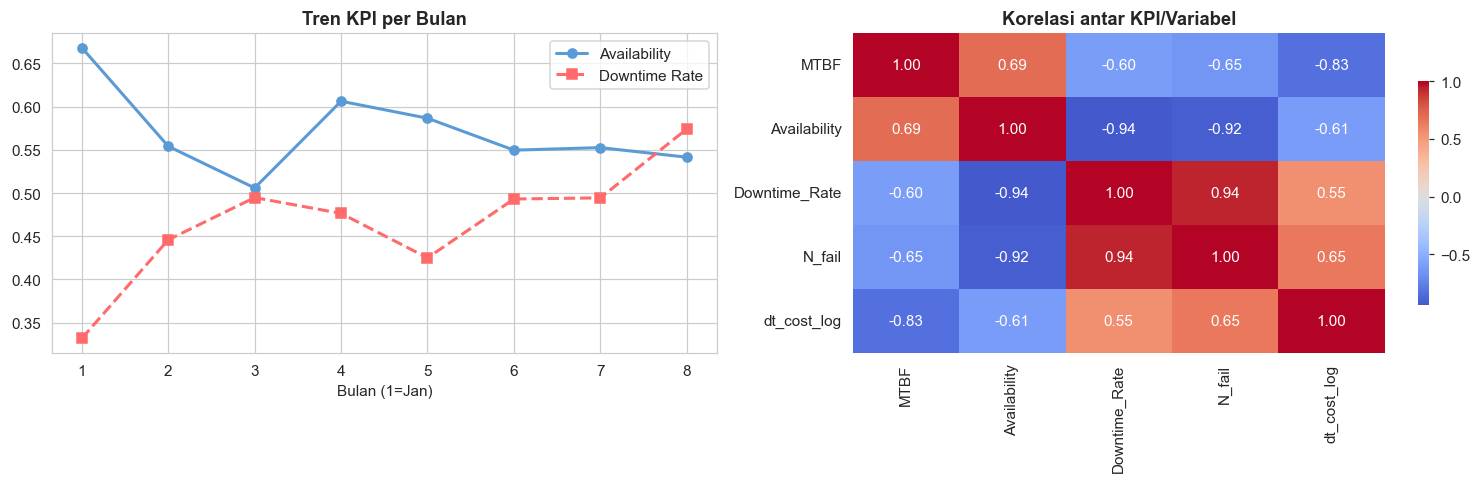

Insight: Availability & Downtime Rate berkebalikan; MTBF searah Availability.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
mb = panel.groupby('midx')[['Availability','Downtime_Rate']].mean()
ax[0].plot(mb.index, mb['Availability'], 'o-', color='#5B9BD5', lw=2, label='Availability')
ax[0].plot(mb.index, mb['Downtime_Rate'], 's--', color='#FF6B6B', lw=2, label='Downtime Rate')
ax[0].set_title('Tren KPI per Bulan', fontweight='bold'); ax[0].set_xlabel('Bulan (1=Jan)'); ax[0].legend()
sns.heatmap(panel[['MTBF','Availability','Downtime_Rate','N_fail','dt_cost_log']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1], cbar_kws={'shrink':.7})
ax[1].set_title('Korelasi antar KPI/Variabel', fontweight='bold')
plt.tight_layout(); plt.show()
print('Insight: Availability & Downtime Rate berkebalikan; MTBF searah Availability.')

---
## Phase 5 — Definisi Target Failure (BAB 3.3.4)

Dataset **tidak menyediakan label kegagalan eksplisit** (tidak ada kolom failure; semua baris `Unplanned Down`, dan tidak ada catatan *Planned Maintenance* sebagai kelas pembanding). Sesuai asumsi terdokumentasi, kondisi kegagalan didefinisikan berbasis keandalan:

> **`failure = 1` bila `MTBF < median(MTBF)`** (equipment-bulan dengan keandalan rendah).

**Menghindari leakage:** karena MTBF mendefinisikan target, KPI **tidak** dipakai sebagai prediktor. Prediktor Logistic Regression = **variabel konteks** (komponen, bulan, biaya downtime log).

> *Catatan:* FRS **bukan kolom data**, melainkan **keluaran model** = P(Y=1). Bila ke depan tersedia label kegagalan asli (mis. data Planned vs Unplanned), Y proxy ini cukup diganti tanpa mengubah pipeline.

In [8]:
THR_MTBF = panel['MTBF'].median()
panel['failure'] = (panel['MTBF'] < THR_MTBF).astype(int)
Xdf = pd.get_dummies(panel[['component']], prefix='comp')
Xdf['midx'] = panel['midx'].values; Xdf['dt_cost_log'] = panel['dt_cost_log'].values
FEATURES = list(Xdf.columns); X = Xdf.values.astype(float); y = panel['failure'].values
print(f'Threshold MTBF (median) = {THR_MTBF:.2f} jam')
print(f'Target: failure={int(y.sum())}, non-failure={int((1-y).sum())} (pos rate {y.mean():.2f})')
print(f'{len(FEATURES)} prediktor:', FEATURES)

Threshold MTBF (median) = 27.97 jam
Target: failure=39, non-failure=39 (pos rate 0.50)
12 prediktor: ['comp_Body/Cabin', 'comp_Brake', 'comp_Driveline/Trans', 'comp_Electrical/Lamp', 'comp_Engine/Fuel', 'comp_Hydraulic', 'comp_Other', 'comp_Steering', 'comp_Suspension', 'comp_Tire/Wheel', 'midx', 'dt_cost_log']


---
## Phase 6 — Logistic Regression (Model Utama, BAB 3.3.4 & 3.6.4)

Train-test split (stratified, `random_state=42`) + `StandardScaler`. Untuk sampel kecil ditampilkan pula **5-Fold CV AUC**.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED).fit(Xtr_s, y_train)
proba_test = logreg.predict_proba(Xte_s)[:,1]; pred_test = logreg.predict(Xte_s)
lr_metrics = dict(Accuracy=accuracy_score(y_test,pred_test), Precision=precision_score(y_test,pred_test,zero_division=0),
    Recall=recall_score(y_test,pred_test,zero_division=0), F1=f1_score(y_test,pred_test,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,proba_test))
sc_all = StandardScaler().fit(X)
cv_auc = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
                         sc_all.transform(X), y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring='roc_auc')
print('===== LOGISTIC REGRESSION — TEST SET =====')
for k,v in lr_metrics.items(): print(f'  {k:10s}: {v:.3f}')
print(f'\n  CV-5 ROC-AUC : {cv_auc.mean():.3f} (+/- {cv_auc.std():.3f})')
print('\n', classification_report(y_test, pred_test, target_names=['Non-Failure','Failure']))

===== LOGISTIC REGRESSION — TEST SET =====
  Accuracy  : 0.800
  Precision : 0.800
  Recall    : 0.800
  F1        : 0.800
  ROC_AUC   : 0.850

  CV-5 ROC-AUC : 0.887 (+/- 0.105)

               precision    recall  f1-score   support

 Non-Failure       0.80      0.80      0.80        10
     Failure       0.80      0.80      0.80        10

    accuracy                           0.80        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.80      0.80      0.80        20



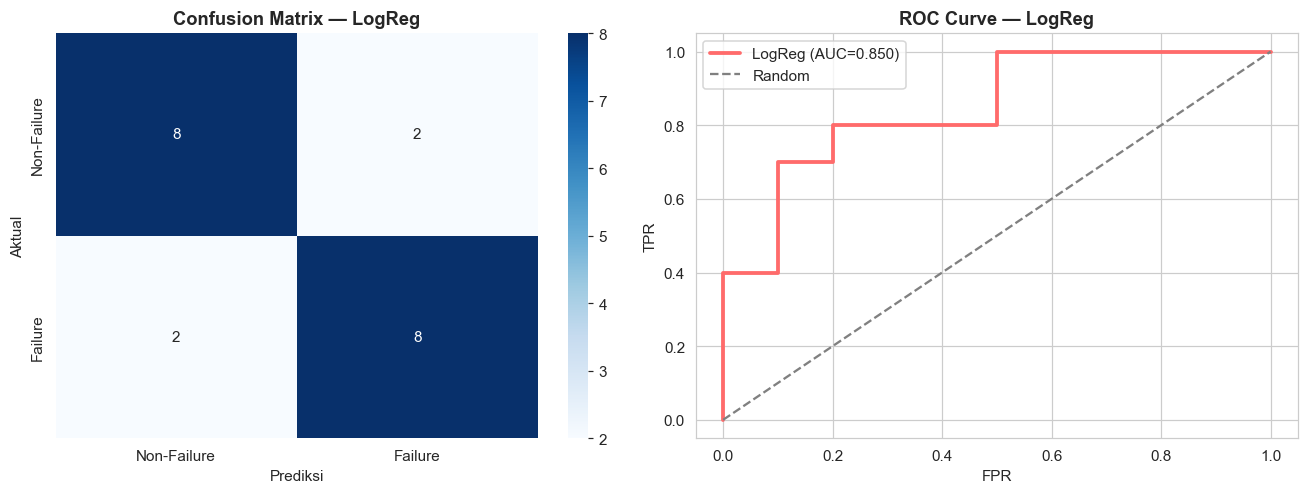

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Non-Failure','Failure'], yticklabels=['Non-Failure','Failure'])
ax[0].set_xlabel('Prediksi'); ax[0].set_ylabel('Aktual'); ax[0].set_title('Confusion Matrix — LogReg', fontweight='bold')
fpr, tpr, _ = roc_curve(y_test, proba_test); auc_val = lr_metrics['ROC_AUC']
ax[1].plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'LogReg (AUC={auc_val:.3f})'); ax[1].plot([0,1],[0,1],'--',color='gray',label='Random')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC Curve — LogReg', fontweight='bold'); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'confusion_matrix.png'), dpi=130, bbox_inches='tight')
fig.savefig(os.path.join(DIR_OUTPUTS,'roc_curve.png'), dpi=130, bbox_inches='tight'); plt.show()

---
## Phase 7 — Failure Risk Score Generation

FRS = P(Y=1) untuk tiap (komponen × bulan), diurutkan dari tertinggi.

In [11]:
panel['FRS_prob'] = logreg.predict_proba(scaler.transform(X))[:,1]
panel['FRS'] = (panel['FRS_prob']*100).round(2)
panel['Prediction'] = (panel['FRS_prob'] >= 0.5).astype(int)
frs_table = (panel[['component','midx','N_fail','MTBF','Availability','Downtime_Rate','failure','FRS_prob','FRS','Prediction']]
             .rename(columns={'component':'Equipment','midx':'Month','failure':'Actual','FRS_prob':'Probability'})
             .sort_values('FRS', ascending=False).reset_index(drop=True))
for c in ['MTBF','Availability','Downtime_Rate','Probability']: frs_table[c]=frs_table[c].round(3)
frs_table.to_csv(os.path.join(DIR_OUTPUTS,'failure_risk_score.csv'), index=False)
print('Tersimpan: outputs/failure_risk_score.csv')
frs_table.head(10)

Tersimpan: outputs/failure_risk_score.csv


,Equipment,Month,N_fail,MTBF,Availability,Downtime_Rate,Actual,Probability,FRS,Prediction
0,Engine/Fuel,1,49,6.211,0.409,0.591,1,0.993,99.33,1
1,Engine/Fuel,6,50,0.020,0.001,1.076,1,0.990,98.95,1
2,Other,6,58,0.017,0.001,1.349,1,0.989,98.91,1
3,Other,7,61,0.016,0.001,1.333,1,0.984,98.39,1
4,Other,8,76,0.013,0.001,2.154,1,0.981,98.14,1
5,Engine/Fuel,7,49,0.020,0.001,1.134,1,0.980,98.03,1
6,Engine/Fuel,4,55,0.018,0.001,1.197,1,0.977,97.71,1
7,Other,4,69,0.014,0.001,1.627,1,0.967,96.75,1
8,Engine/Fuel,3,51,0.020,0.001,1.005,1,0.965,96.54,1
9,Engine/Fuel,2,46,6.040,0.413,0.587,1,0.963,96.28,1


---
## Phase 8 — Model Interpretation (BAB 4)

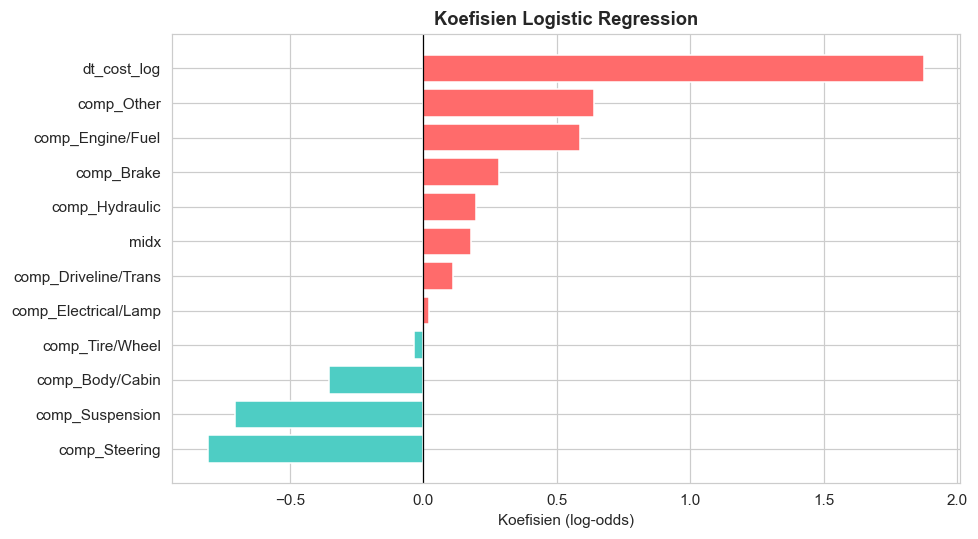

,feature,coef,odds_ratio
0,dt_cost_log,1.874049,6.515
1,comp_Other,0.640189,1.897
2,comp_Engine/Fuel,0.587758,1.800
3,comp_Brake,0.281906,1.326
4,comp_Hydraulic,0.196914,1.218
5,midx,0.179318,1.196
6,comp_Driveline/Trans,0.111974,1.118
7,comp_Electrical/Lamp,0.021160,1.021
8,comp_Tire/Wheel,-0.035334,0.965
9,comp_Body/Cabin,-0.353379,0.702


In [12]:
coef = (pd.DataFrame({'feature':FEATURES,'coef':logreg.coef_[0]}).sort_values('coef', ascending=False).reset_index(drop=True))
coef['odds_ratio'] = np.exp(coef['coef']).round(3)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(coef['feature'], coef['coef'], color=['#FF6B6B' if c>0 else '#4ECDC4' for c in coef['coef']], edgecolor='white')
ax.axvline(0,color='k',lw=.8); ax.invert_yaxis()
ax.set_title('Koefisien Logistic Regression', fontweight='bold'); ax.set_xlabel('Koefisien (log-odds)')
plt.tight_layout(); plt.savefig(os.path.join(DIR_OUTPUTS,'feature_importance.png'), dpi=130, bbox_inches='tight'); plt.show()
coef

---
## Phase 9 — Pengujian Proposisi Analitis 2 (BAB 3)

> **Proposisi 2:** Indikator **Maintenance KPI** (MTBF, Availability, Downtime Rate) berkaitan dengan variasi indikator **nilai operasional**: **Downtime Cost**, **Production Loss**, **Maintenance Budget Variance**.

**Level analisis = blok harian operasional (n≈241).** Indikator nilai tercatat per blok tanggal (fleet-wide), bukan per komponen — sehingga pengujian dilakukan di level blok tempat indikator tersebut bermakna. KPI dihitung ulang per blok. Uji **korelasi Pearson** (α=0,05).

> *Catatan:* pada level blok harian, Scheduled Time per blok = Σ Planned Operating Time, sehingga **MTBF, Availability, dan Downtime Rate menjadi transformasi linear satu sama lain** → besar |r| identik untuk ketiganya, hanya tandanya berbeda.

In [13]:
blk = (df.groupby('block')
         .agg(N_fail=('DT_Hours','size'), DT_total=('DT_Hours','sum'), Sched=('Planned','sum'),
              DowntimeCost=('DT_Cost','first'), ProductionLoss=('ProdLoss','first'),
              BudgetVariance=('BudgetVar','first'))
         .reset_index())
blk['Operating']     = (blk['Sched'] - blk['DT_total']).clip(lower=1.0)
blk['MTBF']          = blk['Operating'] / blk['N_fail']
blk['Availability']  = blk['Operating'] / blk['Sched']
blk['Downtime_Rate'] = blk['DT_total'] / blk['Sched']
print('Jumlah blok harian:', len(blk))

rows = []
for kpi in ['MTBF','Availability','Downtime_Rate']:
    for val,label in [('DowntimeCost','Downtime Cost'),('ProductionLoss','Production Loss'),('BudgetVariance','Budget Variance')]:
        r,p = pearsonr(blk[kpi], blk[val])
        rows.append({'KPI':kpi,'Nilai_Operasional':label,'pearson_r':round(r,3),
                     'p_value':p,'signifikan(α=0.05)':'Ya' if p<0.05 else 'Tidak'})
prop2 = pd.DataFrame(rows)
prop2.to_csv(os.path.join(DIR_OUTPUTS,'proposisi2_correlation.csv'), index=False)
prop2

Jumlah blok harian: 241


,KPI,Nilai_Operasional,pearson_r,p_value,signifikan(α=0.05)
0,MTBF,Downtime Cost,0.179,5.257131e-03,Ya
1,MTBF,Production Loss,-0.738,1.051351e-42,Ya
2,MTBF,Budget Variance,-0.094,1.476560e-01,Tidak
3,Availability,Downtime Cost,0.179,5.257131e-03,Ya
4,Availability,Production Loss,-0.738,1.051351e-42,Ya
5,Availability,Budget Variance,-0.094,1.476560e-01,Tidak
6,Downtime_Rate,Downtime Cost,-0.179,5.257131e-03,Ya
7,Downtime_Rate,Production Loss,0.738,1.051351e-42,Ya
8,Downtime_Rate,Budget Variance,0.094,1.476560e-01,Tidak


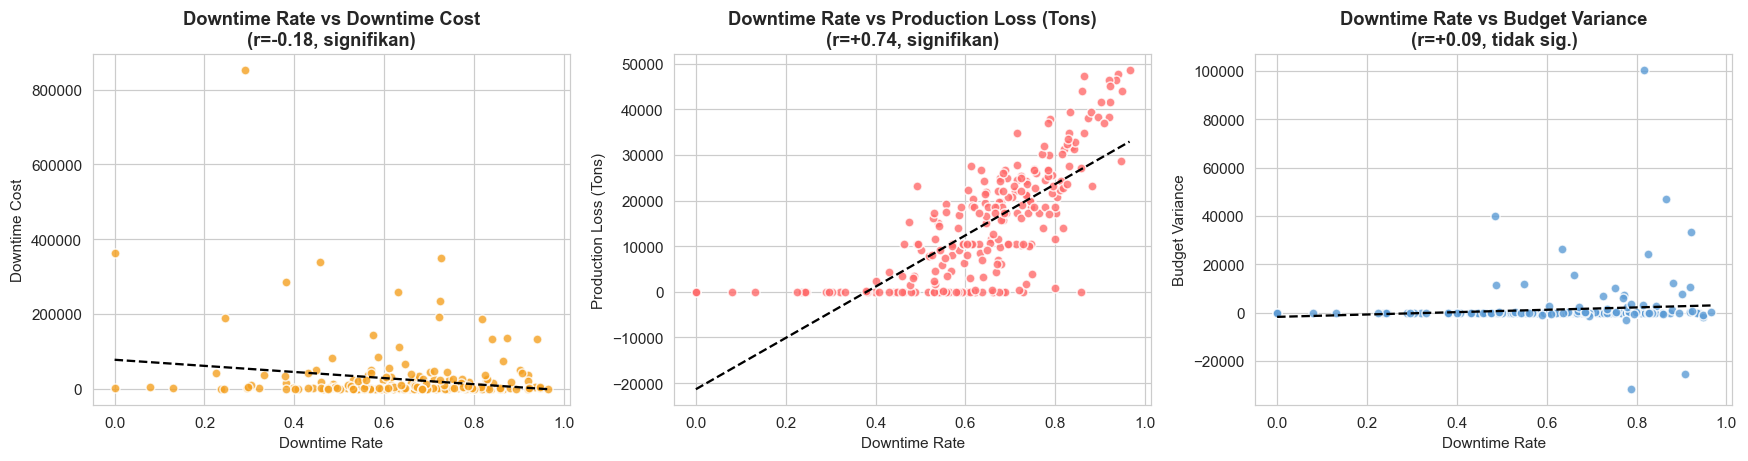

In [14]:
# Scatter Downtime Rate vs tiap indikator nilai
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for a,(val,ttl,c) in zip(ax, [('DowntimeCost','Downtime Cost','#F4A020'),
                               ('ProductionLoss','Production Loss (Tons)','#FF6B6B'),
                               ('BudgetVariance','Budget Variance','#5B9BD5')]):
    a.scatter(blk['Downtime_Rate'], blk[val], color=c, edgecolor='white', s=35, alpha=.8)
    rr,pp = pearsonr(blk['Downtime_Rate'], blk[val])
    b1,b0 = np.polyfit(blk['Downtime_Rate'], blk[val], 1)
    xs = np.linspace(blk['Downtime_Rate'].min(), blk['Downtime_Rate'].max(), 50)
    a.plot(xs, b1*xs+b0, 'k--', lw=1.5)
    sig = 'signifikan' if pp<0.05 else 'tidak sig.'
    a.set_xlabel('Downtime Rate'); a.set_ylabel(ttl)
    a.set_title(f'Downtime Rate vs {ttl}\n(r={rr:+.2f}, {sig})', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(DIR_OUTPUTS,'proposisi2_scatter.png'), dpi=130, bbox_inches='tight'); plt.show()

### Interpretasi Proposisi 2 (bahasa BAB 4)

> Hasil uji korelasi Pearson menunjukkan hubungan **kuat dan signifikan** antara indikator Maintenance KPI dan **Production Loss**: semakin rendah keandalan (MTBF/Availability turun, Downtime Rate naik), semakin besar kehilangan produksi (r ≈ +0,74 terhadap Downtime Rate, p < 0,001). Arah hubungan **konsisten secara teoretis** dan menjadi bukti terkuat pendukung Proposisi 2.
>
> Untuk **Downtime Cost**, korelasinya **lemah** (|r| ≈ 0,18); meski signifikan secara statistik (efek ukuran sampel besar), **besar dan arah hubungannya tidak meyakinkan** — diduga karena kolom `DT Cost (avg/day)` sangat *noisy* dengan sebaran nilai ekstrem. Untuk **Maintenance Budget Variance**, hubungan **tidak signifikan** karena selisih anggaran vs realisasi hampir nol di mayoritas bulan dan baru menonjol pada **Juli–Agustus** (variasi terlalu terkonsentrasi).
>
> Dengan demikian **Proposisi 2 didukung sebagian**: **terdukung kuat pada Production Loss**, namun **belum meyakinkan pada Downtime Cost** dan **belum terdukung pada Budget Variance**.

---
## Phase 10 — Model Pembanding (Random Forest)

In [15]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1).fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:,1]; rf_pred = rf.predict(X_test)
rf_metrics = dict(Accuracy=accuracy_score(y_test,rf_pred), Precision=precision_score(y_test,rf_pred,zero_division=0),
    Recall=recall_score(y_test,rf_pred,zero_division=0), F1=f1_score(y_test,rf_pred,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,rf_proba))
comparison = pd.DataFrame([
    dict(Model='Logistic Regression (Utama)', **{k:round(v,3) for k,v in lr_metrics.items()}),
    dict(Model='Random Forest (Pembanding)',  **{k:round(v,3) for k,v in rf_metrics.items()})])
comparison.to_csv(os.path.join(DIR_OUTPUTS,'model_comparison.csv'), index=False)
best_auc = comparison.loc[comparison['ROC_AUC'].idxmax(),'Model']; best_rec = comparison.loc[comparison['Recall'].idxmax(),'Model']
print('Terbaik ROC-AUC:', best_auc, '| Terbaik Recall:', best_rec, '| Paling interpretable: Logistic Regression')
comparison

Terbaik ROC-AUC: Random Forest (Pembanding) | Terbaik Recall: Random Forest (Pembanding) | Paling interpretable: Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (Utama),0.80,0.800,0.8,0.800,0.850
1,Random Forest (Pembanding),0.85,0.818,0.9,0.857,0.885


In [16]:
joblib.dump(logreg, os.path.join(DIR_MODELS,'logistic_regression.pkl'))
joblib.dump(rf,     os.path.join(DIR_MODELS,'random_forest.pkl'))
joblib.dump(scaler, os.path.join(DIR_MODELS,'scaler.pkl'))
print('Model tersimpan:', os.listdir(DIR_MODELS))

Model tersimpan: ['logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl']


---
## Keterbatasan Dataset (BAB 4/5 — Saran)

1. **Tidak ada ID unit peralatan** → "equipment-level" diaproksimasi dengan **kategori komponen**. Idealnya ID aset nyata.
2. **Tidak ada label kegagalan eksplisit** → target diturunkan dari ambang **MTBF < median** (proxy). Tidak ada catatan *Planned Maintenance* sebagai kelas non-failure. Bila label asli tersedia, Y tinggal diganti.
3. **Panel kecil (≈78 baris)** untuk model FRS → divalidasi tambahan dengan **5-Fold CV**; generalisasi lintas tahun belum diuji.
4. **Tidak ada telemetri kondisi** (getaran, suhu, jam mesin) → prediksi hanya dari catatan downtime, bukan *condition monitoring*.
5. **Proposisi 2 di level blok harian, bukan komponen** — indikator nilai (cost/loss/budget) tercatat per tanggal (fleet-wide), tidak bisa diatribusikan akurat ke komponen. Pada level ini ketiga KPI menjadi transformasi linear (|r| identik).
6. **Maintenance Budget Variance ≈ 0** pada mayoritas bulan (perbedaan signifikan hanya Jul–Agu) → korelasinya tidak signifikan & terkonsentrasi; bukan error, melainkan karakter data.
7. **`Downtime Rate` dapat >1** pada sebagian panel komponen-bulan akibat akumulasi downtime banyak event sejenis (efek proxy unit) — ditafsirkan sebagai beban downtime relatif.

**Saran lanjutan:** sediakan dataset ber-ID unit + label kegagalan eksplisit + telemetri sensor agar FRS bersifat *condition-based* dan Proposisi diuji per peralatan.

---
## Final Report — Ringkasan Skripsi

In [17]:
n = len(panel); nf = int(panel['failure'].sum())
p2 = prop2.set_index(['KPI','Nilai_Operasional'])
def rr(val): row=prop2[(prop2.KPI=='Downtime_Rate')&(prop2.Nilai_Operasional==val)].iloc[0]; return row['pearson_r'],row['p_value'],row['signifikan(α=0.05)']
report = f'''
============================================================
        FINAL REPORT — PREDICTIVE MAINTENANCE (BAB 3/4)
============================================================
[1] DATASET SUMMARY (panel equipment-bulanan)
    Observasi (komponen x bulan) : {n}    Komponen (proxy unit): {panel.component.nunique()}
    Periode: 8 bulan (Jan-Agu 2025)        Prediktor (konteks): {len(FEATURES)}
    Failure (MTBF<median): {nf} ({nf/n*100:.1f}%)   Non-failure: {n-nf}

[2] LOGISTIC REGRESSION (MODEL UTAMA) - Test Set
    Accuracy : {lr_metrics['Accuracy']:.3f}   Precision: {lr_metrics['Precision']:.3f}
    Recall   : {lr_metrics['Recall']:.3f}   F1       : {lr_metrics['F1']:.3f}
    ROC-AUC  : {lr_metrics['ROC_AUC']:.3f}   CV5-AUC  : {cv_auc.mean():.3f}

[3] PROPOSISI ANALITIS 2 (Pearson KPI vs Nilai Operasional, level blok n={len(blk)})
    Downtime Rate ~ Production Loss : r={rr('Production Loss')[0]:+.3f} (p={rr('Production Loss')[1]:.2g}) -> {rr('Production Loss')[2]}
    Downtime Rate ~ Downtime Cost   : r={rr('Downtime Cost')[0]:+.3f} (p={rr('Downtime Cost')[1]:.2g}) -> {rr('Downtime Cost')[2]}
    Downtime Rate ~ Budget Variance : r={rr('Budget Variance')[0]:+.3f} (p={rr('Budget Variance')[1]:.2g}) -> {rr('Budget Variance')[2]}
    -> Proposisi 2 DIDUKUNG SEBAGIAN (kuat: Production Loss; lemah-sig: Downtime Cost; tidak: Budget Variance).

[4] PERBANDINGAN MODEL
    Terbaik ROC-AUC: {best_auc} | Terbaik Recall: {best_rec}
    -> Sesuai metodologi, LOGISTIC REGRESSION = model utama; RF = validasi searah.
============================================================
'''
print(report)


        FINAL REPORT — PREDICTIVE MAINTENANCE (BAB 3/4)
[1] DATASET SUMMARY (panel equipment-bulanan)
    Observasi (komponen x bulan) : 78    Komponen (proxy unit): 10
    Periode: 8 bulan (Jan-Agu 2025)        Prediktor (konteks): 12
    Failure (MTBF<median): 39 (50.0%)   Non-failure: 39

[2] LOGISTIC REGRESSION (MODEL UTAMA) - Test Set
    Accuracy : 0.800   Precision: 0.800
    Recall   : 0.800   F1       : 0.800
    ROC-AUC  : 0.850   CV5-AUC  : 0.887

[3] PROPOSISI ANALITIS 2 (Pearson KPI vs Nilai Operasional, level blok n=241)
    Downtime Rate ~ Production Loss : r=+0.738 (p=1.1e-42) -> Ya
    Downtime Rate ~ Downtime Cost   : r=-0.179 (p=0.0053) -> Ya
    Downtime Rate ~ Budget Variance : r=+0.094 (p=0.15) -> Tidak
    -> Proposisi 2 DIDUKUNG SEBAGIAN (kuat: Production Loss; lemah-sig: Downtime Cost; tidak: Budget Variance).

[4] PERBANDINGAN MODEL
    Terbaik ROC-AUC: Random Forest (Pembanding) | Terbaik Recall: Random Forest (Pembanding)
    -> Sesuai metodologi, LOGISTIC 

In [18]:
def g2(val): row=prop2[(prop2.KPI=='Downtime_Rate')&(prop2.Nilai_Operasional==val)].iloc[0]; return row
md_txt = f'''# Interpretasi Hasil — Predictive Maintenance (BAB 4)

## 1. Ringkasan Dataset
- Unit analisis: equipment-level monthly (komponen sebagai proxy unit) — **{n}** observasi, 8 bulan (Jan–Agu 2025).
- Failure (MTBF<median): **{nf}** ({nf/n*100:.1f}%), Non-failure: **{n-nf}**. Prediktor konteks: **{len(FEATURES)}**.

## 2. Maintenance KPI (BAB 3.3.3)
Dihitung per komponen-bulan: MTBF (jam), Availability, Downtime Rate. Lihat `outputs/kpi_panel.csv`.

## 3. Logistic Regression (Model Utama)
| Metrik | Nilai |
|--------|-------|
| Accuracy | {lr_metrics['Accuracy']:.3f} |
| Precision | {lr_metrics['Precision']:.3f} |
| Recall | {lr_metrics['Recall']:.3f} |
| F1 | {lr_metrics['F1']:.3f} |
| ROC-AUC | {lr_metrics['ROC_AUC']:.3f} |
| CV-5 ROC-AUC | {cv_auc.mean():.3f} (±{cv_auc.std():.3f}) |

## 4. Proposisi Analitis 2 — Korelasi Pearson KPI vs Nilai Operasional (level blok harian, n={len(blk)})
| Indikator Nilai | r (vs Downtime Rate) | p-value | Signifikan |
|-----------------|----------------------|---------|-----------|
| Production Loss | {g2('Production Loss')['pearson_r']:+.3f} | {g2('Production Loss')['p_value']:.2g} | {g2('Production Loss')['signifikan(α=0.05)']} |
| Downtime Cost | {g2('Downtime Cost')['pearson_r']:+.3f} | {g2('Downtime Cost')['p_value']:.2g} | {g2('Downtime Cost')['signifikan(α=0.05)']} |
| Budget Variance | {g2('Budget Variance')['pearson_r']:+.3f} | {g2('Budget Variance')['p_value']:.2g} | {g2('Budget Variance')['signifikan(α=0.05)']} |

**Kesimpulan:** Proposisi 2 **didukung sebagian** — keandalan rendah berhubungan **kuat & signifikan dengan kenaikan Production Loss**; hubungan dengan **Downtime Cost lemah/tidak meyakinkan** (kolom biaya sangat noisy) dan dengan **Budget Variance tidak signifikan** (variansnya terkonsentrasi di Jul–Agu).

## 5. Perbandingan Model
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression (utama) | {lr_metrics['Accuracy']:.3f} | {lr_metrics['Precision']:.3f} | {lr_metrics['Recall']:.3f} | {lr_metrics['F1']:.3f} | {lr_metrics['ROC_AUC']:.3f} |
| Random Forest (pembanding) | {rf_metrics['Accuracy']:.3f} | {rf_metrics['Precision']:.3f} | {rf_metrics['Recall']:.3f} | {rf_metrics['F1']:.3f} | {rf_metrics['ROC_AUC']:.3f} |

## 6. Kesesuaian Metodologi (Thesis Notes)
Pemodelan mengikuti BAB 3: KPI keandalan di level equipment-bulanan, Logistic Regression menghasilkan Failure Risk Score, divalidasi train-test split + metrik confusion matrix, dan **Proposisi Analitis 2** diuji dengan korelasi Pearson KPI ↔ indikator nilai operasional. Logistic Regression tetap model utama; Random Forest pembanding. Keterbatasan: tanpa ID unit & label asli & telemetri; Proposisi 2 di level blok harian; Budget Variance terkonsentrasi Jul–Agu.
'''
with open(os.path.join(DIR_REPORT,'interpretation.md'),'w',encoding='utf-8') as f: f.write(md_txt)
print('Tersimpan: report/interpretation.md')

Tersimpan: report/interpretation.md


---
## Kesimpulan

| Aspek (BAB 3) | Status |
|---|---|
| Perhitungan Maintenance KPI (MTBF, Availability, Downtime Rate) | ✔ |
| Logistic Regression → Failure Risk Score | ✔ (model utama) |
| Validasi train-test + Accuracy/Precision/Recall/AUC-ROC + CM | ✔ |
| **Proposisi Analitis 2** (Pearson KPI ↔ nilai operasional) | ✔ (didukung sebagian) |
| Model pembanding (Random Forest, 1 metode) | ✔ |
| Keterbatasan & saran | ✔ |

**Thesis Notes:** Hasil **sesuai metodologi BAB 3**. Logistic Regression menghasilkan Failure Risk Score; Proposisi Analitis 2 menunjukkan keandalan rendah berkaitan **kuat & signifikan dengan kenaikan Production Loss**, sedangkan hubungan dengan Downtime Cost lemah dan dengan Budget Variance tidak signifikan (terkonsentrasi Jul–Agu). Interpretasi bersifat analitis-deskriptif (non-kausal), selaras posisi metodologi. Keterbatasan utama: tanpa ID unit, label kegagalan asli, dan telemetri sensor.